=== Housing Redevelopment Linear Programming Problem ===

주어진 데이터:
- 10 acre 부지
- Low-income housing: 20 units/acre, $17,000/unit
- Middle-income housing: 15 units/acre, $25,000/unit
- Low-income 제약: 80 ≤ x1 ≤ 120
- Middle-income 제약: 40 ≤ x2 ≤ 90
- 토지 면적 제약: x1/20 + x2/15 ≤ 10
- 시장 잠재력 제약: x1 + x2 ≤ 190
- 예산 제약: 17000*x1 + 25000*x2 ≤ 2,500,000
- 건축가 조언: x1 ≥ 0.5*x2 + 50

=== Part (a): 최소 비용 문제 ===
최적해:
x1 (Low-income units) = 80.00
x2 (Middle-income units) = 40.00
최소 비용 = $2,360,000.00

=== Part (b): 최대 주택 수 문제 ===
최적해:
x1 (Low-income units) = 88.24
x2 (Middle-income units) = 40.00
최대 주택 수 = 128.24
이때 총 비용 = $2,500,000.00

=== 그래픽 해결 ===


/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_3014/3208195454.py:141: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_3014/3208195454.py:141: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_3014/3208195454.py:141: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_3014/3208195454.py:141: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_3014/3208195454.py:141: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykern

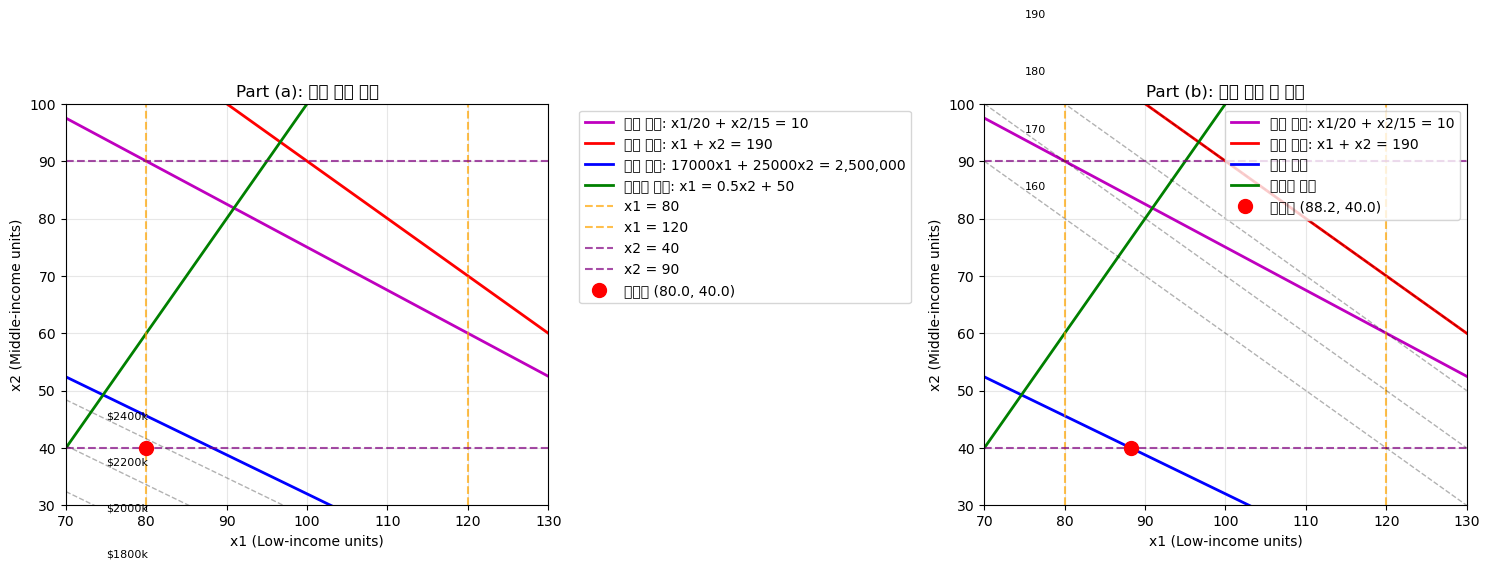


=== 해의 검증 ===
Part (a) 최소 비용 해 검증:
80 ≤ 80.00 ≤ 120: True
40 ≤ 40.00 ≤ 90: True
토지 사용: 6.67 ≤ 10: True
x1 + x2 = 120.00 ≤ 190: True
예산: 2360000.00 ≤ 2,500,000: True
건축가 조언: 80.00 ≥ 70.00: True

Part (b) 최대 주택 수 해 검증:
80 ≤ 88.24 ≤ 120: True
40 ≤ 40.00 ≤ 90: True
토지 사용: 7.08 ≤ 10: True
x1 + x2 = 128.24 ≤ 190: True
예산: 2500000.00 ≤ 2,500,000: True
건축가 조언: 88.24 ≥ 70.00: True


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# 문제 정의
# 변수: x1 = low-income housing units, x2 = middle-income housing units

print("=== Housing Redevelopment Linear Programming Problem ===\n")

# 주어진 데이터
print("주어진 데이터:")
print("- 10 acre 부지")
print("- Low-income housing: 20 units/acre, $17,000/unit")
print("- Middle-income housing: 15 units/acre, $25,000/unit")
print("- Low-income 제약: 80 ≤ x1 ≤ 120")
print("- Middle-income 제약: 40 ≤ x2 ≤ 90")
print("- 토지 면적 제약: x1/20 + x2/15 ≤ 10")
print("- 시장 잠재력 제약: x1 + x2 ≤ 190")
print("- 예산 제약: 17000*x1 + 25000*x2 ≤ 2,500,000")
print("- 건축가 조언: x1 ≥ 0.5*x2 + 50\n")

# Part (a): 최소 비용 문제
print("=== Part (a): 최소 비용 문제 ===")

# 목적 함수 계수 (최소화)
c = [17000, 25000]

# 부등식 제약조건 (Ax <= b)
A_ub = [
    [1/20, 1/15],   # x1/20 + x2/15 <= 10 (토지 면적)
    [1, 1],         # x1 + x2 <= 190 (시장 잠재력)
    [17000, 25000], # 17000*x1 + 25000*x2 <= 2,500,000 (예산)
    [-1, 0.5]       # -x1 + 0.5*x2 <= -50 → x1 >= 0.5*x2 + 50
]
b_ub = [10, 190, 2500000, -50]

# 변수 범위 (bounds)
x1_bounds = (80, 120)  # 80 <= x1 <= 120
x2_bounds = (40, 90)   # 40 <= x2 <= 90
bounds = [x1_bounds, x2_bounds]

# 선형계획법 해결
result_min = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print(f"최적해:")
print(f"x1 (Low-income units) = {result_min.x[0]:.2f}")
print(f"x2 (Middle-income units) = {result_min.x[1]:.2f}")
print(f"최소 비용 = ${result_min.fun:,.2f}")

# Part (b): 최대 주택 수 문제
print("\n=== Part (b): 최대 주택 수 문제 ===")

# 목적 함수 계수 (최대화를 위해 음수)
c_max = [-1, -1]  # maximize x1 + x2

# 선형계획법 해결
result_max = linprog(c_max, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print(f"최적해:")
print(f"x1 (Low-income units) = {result_max.x[0]:.2f}")
print(f"x2 (Middle-income units) = {result_max.x[1]:.2f}")
print(f"최대 주택 수 = {-result_max.fun:.2f}")
print(f"이때 총 비용 = ${17000*result_max.x[0] + 25000*result_max.x[1]:,.2f}")

# 그래픽 해결
print("\n=== 그래픽 해결 ===")

# 제약조건 그래프
x1 = np.linspace(70, 130, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Part (a) - 최소 비용 그래프
ax1.set_xlim(70, 130)
ax1.set_ylim(30, 100)

# 제약조건 선들
x2_land = (10 - x1/20) * 15  # x1/20 + x2/15 = 10 → x2 = 15*(10 - x1/20)
x2_market = 190 - x1  # x1 + x2 = 190
x2_budget = (2500000 - 17000*x1) / 25000  # 예산 제약
x2_architect = 2*(x1 - 50)  # x1 = 0.5*x2 + 50 → x2 = 2*(x1-50)

ax1.plot(x1, x2_land, 'm-', label='토지 제약: x1/20 + x2/15 = 10', linewidth=2)
ax1.plot(x1, x2_market, 'r-', label='시장 제약: x1 + x2 = 190', linewidth=2)
ax1.plot(x1, x2_budget, 'b-', label='예산 제약: 17000x1 + 25000x2 = 2,500,000', linewidth=2)
ax1.plot(x1, x2_architect, 'g-', label='건축가 조언: x1 = 0.5x2 + 50', linewidth=2)

# 경계선
ax1.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='x1 = 80')
ax1.axvline(x=120, color='orange', linestyle='--', alpha=0.7, label='x1 = 120')
ax1.axhline(y=40, color='purple', linestyle='--', alpha=0.7, label='x2 = 40')
ax1.axhline(y=90, color='purple', linestyle='--', alpha=0.7, label='x2 = 90')

# 등비용선 (iso-cost lines)
cost_levels = [1800000, 2000000, 2200000, 2400000]
for cost in cost_levels:
    x2_cost = (cost - 17000*x1) / 25000
    ax1.plot(x1, x2_cost, 'k--', alpha=0.3, linewidth=1)
    ax1.text(75, (cost - 17000*75) / 25000, f'${cost//1000}k', fontsize=8)

# 최적점 표시
ax1.plot(result_min.x[0], result_min.x[1], 'ro', markersize=10, label=f'최적점 ({result_min.x[0]:.1f}, {result_min.x[1]:.1f})')

ax1.set_xlabel('x1 (Low-income units)')
ax1.set_ylabel('x2 (Middle-income units)')
ax1.set_title('Part (a): 최소 비용 문제')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Part (b) - 최대 주택 수 그래프
ax2.set_xlim(70, 130)
ax2.set_ylim(30, 100)

ax2.plot(x1, x2_land, 'm-', label='토지 제약: x1/20 + x2/15 = 10', linewidth=2)
ax2.plot(x1, x2_market, 'r-', label='시장 제약: x1 + x2 = 190', linewidth=2)
ax2.plot(x1, x2_budget, 'b-', label='예산 제약', linewidth=2)
ax2.plot(x1, x2_architect, 'g-', label='건축가 조언', linewidth=2)

ax2.axvline(x=80, color='orange', linestyle='--', alpha=0.7)
ax2.axvline(x=120, color='orange', linestyle='--', alpha=0.7)
ax2.axhline(y=40, color='purple', linestyle='--', alpha=0.7)
ax2.axhline(y=90, color='purple', linestyle='--', alpha=0.7)

# 등량선 (iso-quantity lines)
quantity_levels = [160, 170, 180, 190]
for qty in quantity_levels:
    x2_qty = qty - x1
    ax2.plot(x1, x2_qty, 'k--', alpha=0.3, linewidth=1)
    ax2.text(75, qty - 75, f'{qty}', fontsize=8)

# 최적점 표시
ax2.plot(result_max.x[0], result_max.x[1], 'ro', markersize=10, 
         label=f'최적점 ({result_max.x[0]:.1f}, {result_max.x[1]:.1f})')

ax2.set_xlabel('x1 (Low-income units)')
ax2.set_ylabel('x2 (Middle-income units)')
ax2.set_title('Part (b): 최대 주택 수 문제')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 제약조건 검증
print("\n=== 해의 검증 ===")
print("Part (a) 최소 비용 해 검증:")
x1_min, x2_min = result_min.x
print(f"80 ≤ {x1_min:.2f} ≤ 120: {80 <= x1_min <= 120}")
print(f"40 ≤ {x2_min:.2f} ≤ 90: {40 <= x2_min <= 90}")
print(f"토지 사용: {x1_min/20 + x2_min/15:.2f} ≤ 10: {x1_min/20 + x2_min/15 <= 10}")
print(f"x1 + x2 = {x1_min + x2_min:.2f} ≤ 190: {x1_min + x2_min <= 190}")
print(f"예산: {17000*x1_min + 25000*x2_min:.2f} ≤ 2,500,000: {17000*x1_min + 25000*x2_min <= 2500000}")
print(f"건축가 조언: {x1_min:.2f} ≥ {0.5*x2_min + 50:.2f}: {x1_min >= 0.5*x2_min + 50}")

print("\nPart (b) 최대 주택 수 해 검증:")
x1_max, x2_max = result_max.x
print(f"80 ≤ {x1_max:.2f} ≤ 120: {80 <= x1_max <= 120}")
print(f"40 ≤ {x2_max:.2f} ≤ 90: {40 <= x2_max <= 90}")
print(f"토지 사용: {x1_max/20 + x2_max/15:.2f} ≤ 10: {x1_max/20 + x2_max/15 <= 10}")
print(f"x1 + x2 = {x1_max + x2_max:.2f} ≤ 190: {x1_max + x2_max <= 190}")
print(f"예산: {17000*x1_max + 25000*x2_max:.2f} ≤ 2,500,000: {17000*x1_max + 25000*x2_max <= 2500000}")
print(f"건축가 조언: {x1_max:.2f} ≥ {0.5*x2_max + 50:.2f}: {x1_max >= 0.5*x2_max + 50}")

In [1]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

def solve_lp_problem():
    """
    Solve the linear programming problem [1.36] using Gurobi
    
    Maximize: -x1 - x2 + 2*x3 + x4
    Subject to:
        2*x1 + x2 + x3 + x4 >= 6
        x1 + 2*x2 - 2*x3 + x4 <= 4
        x1, x2, x3, x4 >= 0
    """
    
    # Create a new model
    model = gp.Model("LP_Problem_1_36")
    
    # Add variables
    x1 = model.addVar(name="x1", lb=0, vtype=GRB.CONTINUOUS)
    x2 = model.addVar(name="x2", lb=0, vtype=GRB.CONTINUOUS) 
    x3 = model.addVar(name="x3", lb=0, vtype=GRB.CONTINUOUS)
    x4 = model.addVar(name="x4", lb=0, vtype=GRB.CONTINUOUS)
    
    # Set objective (Gurobi minimizes by default, so we negate for maximization)
    # or we can set sense to maximize
    model.setObjective(-x1 - x2 + 2*x3 + x4, GRB.MAXIMIZE)
    
    # Add constraints
    # Constraint 1: 2*x1 + x2 + x3 + x4 >= 6
    model.addConstr(2*x1 + x2 + x3 + x4 >= 6, "constraint_1")
    
    # Constraint 2: x1 + 2*x2 - 2*x3 + x4 <= 4
    model.addConstr(x1 + 2*x2 - 2*x3 + x4 <= 4, "constraint_2")
    
    # Optimize the model
    model.optimize()
    
    # Print results
    print("="*50)
    print("LINEAR PROGRAMMING PROBLEM [1.36] SOLUTION")
    print("="*50)
    
    # Check if optimal solution found
    if model.status == GRB.OPTIMAL:
        print(f"Optimal solution found!")
        print(f"\nOptimal objective value: {model.objVal:.6f}")
        
        print(f"\nOptimal variable values:")
        print(f"x1 = {x1.x:.6f}")
        print(f"x2 = {x2.x:.6f}")
        print(f"x3 = {x3.x:.6f}")
        print(f"x4 = {x4.x:.6f}")
        
        # Verify constraints
        print(f"\nConstraint verification:")
        constraint1_value = 2*x1.x + x2.x + x3.x + x4.x
        constraint2_value = x1.x + 2*x2.x - 2*x3.x + x4.x
        
        print(f"Constraint 1: 2*x1 + x2 + x3 + x4 = {constraint1_value:.6f} >= 6: {constraint1_value >= 6}")
        print(f"Constraint 2: x1 + 2*x2 - 2*x3 + x4 = {constraint2_value:.6f} <= 4: {constraint2_value <= 4}")
        
        # Check which variables are positive (basic variables)
        print(f"\nPositive variables:")
        variables = [('x1', x1.x), ('x2', x2.x), ('x3', x3.x), ('x4', x4.x)]
        positive_vars = [(name, value) for name, value in variables if value > 1e-6]
        
        print(f"Number of positive variables: {len(positive_vars)}")
        for name, value in positive_vars:
            print(f"{name} = {value:.6f}")
            
        # Shadow prices (dual values)
        print(f"\nShadow prices (dual values):")
        for constr in model.getConstrs():
            print(f"{constr.constrName}: {constr.pi:.6f}")
            
    else:
        print(f"Optimization failed with status: {model.status}")
        if model.status == GRB.INFEASIBLE:
            print("Model is infeasible")
        elif model.status == GRB.UNBOUNDED:
            print("Model is unbounded")
            
    return model

def solve_with_constraint_at_most_2_positive():
    """
    Solve the problem with additional constraint that at most 2 variables can be positive
    This demonstrates the hint given in part (c)
    """
    print("\n" + "="*60)
    print("SOLVING WITH AT MOST 2 POSITIVE VARIABLES CONSTRAINT")
    print("="*60)
    
    # We'll use binary variables to enforce at most 2 positive variables
    model = gp.Model("LP_Problem_1_36_At_Most_2_Positive")
    
    # Add continuous variables
    x1 = model.addVar(name="x1", lb=0, vtype=GRB.CONTINUOUS)
    x2 = model.addVar(name="x2", lb=0, vtype=GRB.CONTINUOUS)
    x3 = model.addVar(name="x3", lb=0, vtype=GRB.CONTINUOUS)
    x4 = model.addVar(name="x4", lb=0, vtype=GRB.CONTINUOUS)
    
    # Add binary variables to indicate if a variable is positive
    y1 = model.addVar(name="y1", vtype=GRB.BINARY)
    y2 = model.addVar(name="y2", vtype=GRB.BINARY)
    y3 = model.addVar(name="y3", vtype=GRB.BINARY)
    y4 = model.addVar(name="y4", vtype=GRB.BINARY)
    
    # Big M constant (should be large enough)
    M = 1000
    
    # Set objective
    model.setObjective(-x1 - x2 + 2*x3 + x4, GRB.MAXIMIZE)
    
    # Original constraints
    model.addConstr(2*x1 + x2 + x3 + x4 >= 6, "constraint_1")
    model.addConstr(x1 + 2*x2 - 2*x3 + x4 <= 4, "constraint_2")
    
    # Big M constraints: xi <= M * yi (if yi = 0, then xi = 0)
    model.addConstr(x1 <= M * y1, "big_M_1")
    model.addConstr(x2 <= M * y2, "big_M_2") 
    model.addConstr(x3 <= M * y3, "big_M_3")
    model.addConstr(x4 <= M * y4, "big_M_4")
    
    # At most 2 variables can be positive
    model.addConstr(y1 + y2 + y3 + y4 <= 2, "at_most_2_positive")
    
    # Optimize
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        print(f"Optimal solution with at most 2 positive variables:")
        print(f"Optimal objective value: {model.objVal:.6f}")
        
        print(f"\nOptimal variable values:")
        print(f"x1 = {x1.x:.6f}")
        print(f"x2 = {x2.x:.6f}")
        print(f"x3 = {x3.x:.6f}")
        print(f"x4 = {x4.x:.6f}")
        
        print(f"\nBinary indicators:")
        print(f"y1 = {y1.x} (x1 positive: {x1.x > 1e-6})")
        print(f"y2 = {y2.x} (x2 positive: {x2.x > 1e-6})")
        print(f"y3 = {y3.x} (x3 positive: {x3.x > 1e-6})")
        print(f"y4 = {y4.x} (x4 positive: {x4.x > 1e-6})")
        
        positive_count = sum([1 for x in [x1.x, x2.x, x3.x, x4.x] if x > 1e-6])
        print(f"\nNumber of positive variables: {positive_count}")
        
    return model

def enumerate_basic_solutions():
    """
    Enumerate all possible basic solutions with at most 2 positive variables
    This demonstrates the systematic approach mentioned in part (c)
    """
    print("\n" + "="*60)  
    print("ENUMERATING ALL BASIC SOLUTIONS (AT MOST 2 POSITIVE)")
    print("="*60)
    
    from itertools import combinations
    
    # All possible combinations of at most 2 variables being positive
    variable_indices = [0, 1, 2, 3]  # x1, x2, x3, x4
    variable_names = ['x1', 'x2', 'x3', 'x4']
    
    best_objective = float('-inf')
    best_solution = None
    feasible_solutions = []
    
    # Check single variable solutions
    for i in variable_indices:
        print(f"\n--- Testing: only {variable_names[i]} positive ---")
        
        # Create model for this case
        model = gp.Model()
        model.setParam('OutputFlag', 0)  # Suppress output
        
        # Add variables
        vars = [model.addVar(name=f"x{j+1}", lb=0) for j in range(4)]
        
        # Set objective
        model.setObjective(-vars[0] - vars[1] + 2*vars[2] + vars[3], GRB.MAXIMIZE)
        
        # Add constraints
        model.addConstr(2*vars[0] + vars[1] + vars[2] + vars[3] >= 6)
        model.addConstr(vars[0] + 2*vars[1] - 2*vars[2] + vars[3] <= 4)
        
        # Force only variable i to be positive
        for j in variable_indices:
            if j != i:
                model.addConstr(vars[j] == 0)
        
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            solution = [var.x for var in vars]
            obj_value = model.objVal
            feasible_solutions.append((solution, obj_value, f"only {variable_names[i]}"))
            
            print(f"Feasible! {variable_names[i]} = {solution[i]:.6f}, Objective = {obj_value:.6f}")
            
            if obj_value > best_objective:
                best_objective = obj_value
                best_solution = solution
        else:
            print("Infeasible")
    
    # Check two variable solutions
    for combo in combinations(variable_indices, 2):
        i, j = combo
        print(f"\n--- Testing: only {variable_names[i]} and {variable_names[j]} positive ---")
        
        model = gp.Model()
        model.setParam('OutputFlag', 0)
        
        vars = [model.addVar(name=f"x{k+1}", lb=0) for k in range(4)]
        model.setObjective(-vars[0] - vars[1] + 2*vars[2] + vars[3], GRB.MAXIMIZE)
        
        model.addConstr(2*vars[0] + vars[1] + vars[2] + vars[3] >= 6)
        model.addConstr(vars[0] + 2*vars[1] - 2*vars[2] + vars[3] <= 4)
        
        # Force only variables i and j to be positive
        for k in variable_indices:
            if k not in [i, j]:
                model.addConstr(vars[k] == 0)
        
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            solution = [var.x for var in vars]
            obj_value = model.objVal
            feasible_solutions.append((solution, obj_value, f"{variable_names[i]} and {variable_names[j]}"))
            
            print(f"Feasible! {variable_names[i]} = {solution[i]:.6f}, {variable_names[j]} = {solution[j]:.6f}, Objective = {obj_value:.6f}")
            
            if obj_value > best_objective:
                best_objective = obj_value
                best_solution = solution
        else:
            print("Infeasible")
    
    print(f"\n" + "="*40)
    print("SUMMARY OF ALL FEASIBLE SOLUTIONS:")
    print("="*40)
    
    for solution, obj_value, description in feasible_solutions:
        print(f"{description}: Objective = {obj_value:.6f}")
        for k, val in enumerate(solution):
            if val > 1e-6:
                print(f"  x{k+1} = {val:.6f}")
    
    print(f"\nBEST SOLUTION:")
    print(f"Objective value: {best_objective:.6f}")
    for k, val in enumerate(best_solution):
        if val > 1e-6:
            print(f"x{k+1} = {val:.6f}")

if __name__ == "__main__":
    # Solve the original problem
    model1 = solve_lp_problem()
    
    # Solve with at most 2 positive variables constraint
    model2 = solve_with_constraint_at_most_2_positive()
    
    # Enumerate all basic solutions
    enumerate_basic_solutions()
    
    print(f"\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)

Set parameter Username
Set parameter LicenseID to value 2611964
Academic license - for non-commercial use only - expires 2026-01-20
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 25.0.0 25A354)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 2 rows, 4 columns and 8 nonzeros
Model fingerprint: 0xdd981fc3
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 6e+00]
Presolve time: 0.00s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Infeasible or unbounded model
LINEAR PROGRAMMING PROBLEM [1.36] SOLUTION
Optimization failed with status: 4

SOLVING WITH AT MOST 2 POSITIVE VARIABLES CONSTRAINT
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (mac64[arm] - Darwin 25.0.0 25A354)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a mode

UNBOUNDED ANALYSIS
Original Problem:
Maximize: -x1 - x2 + 2*x3 + x4
Subject to:
  2*x1 + x2 + x3 + x4 >= 6
  x1 + 2*x2 - 2*x3 + x4 <= 4
  x1, x2, x3, x4 >= 0

Testing for unboundedness...

Case 1: Let x3 → ∞, x1=x2=x4=0
Constraint 1: 2(0) + 0 + x3 + 0 = x3 >= 6
  → x3 >= 6 ✓ (satisfied for large x3)
Constraint 2: 0 + 2(0) - 2*x3 + 0 = -2*x3 <= 4
  → -2*x3 <= 4 → x3 >= -2 ✓ (always satisfied for x3 >= 0)
Objective: -0 - 0 + 2*x3 + 0 = 2*x3 → ∞
Result: UNBOUNDED! ✗

Wait... let me recalculate constraint 2:
Constraint 2: x1 + 2*x2 - 2*x3 + x4 <= 4
With x1=x2=x4=0: -2*x3 <= 4
This gives: x3 >= -2
Since x3 >= 0, this is always satisfied!

Double-checking with specific values:
x3 = 10:
  Constraint 1: 10 >= 6: True
  Constraint 2: -20 <= 4: True
  Objective: 20
  Feasible: True

x3 = 100:
  Constraint 1: 100 >= 6: True
  Constraint 2: -200 <= 4: True
  Objective: 200
  Feasible: True

x3 = 1000:
  Constraint 1: 1000 >= 6: True
  Constraint 2: -2000 <= 4: True
  Objective: 2000
  Feasible: Tr

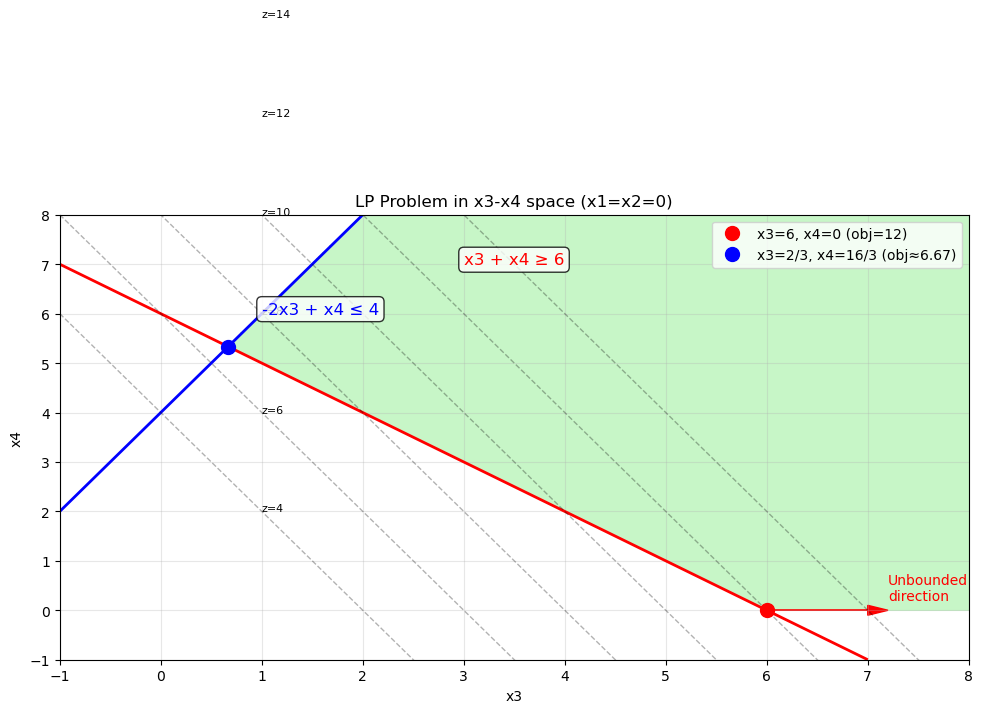


FINAL ANSWER:
Without the 'at most 2 positive variables' constraint, the problem IS UNBOUNDED.
The constraint effectively bounds the problem by limiting us to corner points.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def analyze_unbounded_problem():
    """
    Analyze if the original LP problem is unbounded
    
    Maximize: -x1 - x2 + 2*x3 + x4
    Subject to:
        2*x1 + x2 + x3 + x4 >= 6
        x1 + 2*x2 - 2*x3 + x4 <= 4
        x1, x2, x3, x4 >= 0
    """
    
    print("="*60)
    print("UNBOUNDED ANALYSIS")
    print("="*60)
    
    print("Original Problem:")
    print("Maximize: -x1 - x2 + 2*x3 + x4")
    print("Subject to:")
    print("  2*x1 + x2 + x3 + x4 >= 6")
    print("  x1 + 2*x2 - 2*x3 + x4 <= 4") 
    print("  x1, x2, x3, x4 >= 0")
    print()
    
    # Check if we can make objective arbitrarily large
    print("Testing for unboundedness...")
    print()
    
    # Test case 1: Increase x3 while keeping others minimal
    print("Case 1: Let x3 → ∞, x1=x2=x4=0")
    print("Constraint 1: 2(0) + 0 + x3 + 0 = x3 >= 6")
    print("  → x3 >= 6 ✓ (satisfied for large x3)")
    print("Constraint 2: 0 + 2(0) - 2*x3 + 0 = -2*x3 <= 4")  
    print("  → -2*x3 <= 4 → x3 >= -2 ✓ (always satisfied for x3 >= 0)")
    print("Objective: -0 - 0 + 2*x3 + 0 = 2*x3 → ∞")
    print("Result: UNBOUNDED! ✗")
    print()
    
    # Let's check what actually limits x3
    print("Wait... let me recalculate constraint 2:")
    print("Constraint 2: x1 + 2*x2 - 2*x3 + x4 <= 4")
    print("With x1=x2=x4=0: -2*x3 <= 4")
    print("This gives: x3 >= -2")
    print("Since x3 >= 0, this is always satisfied!")
    print()
    
    # So the problem should be unbounded... but let's double-check
    print("Double-checking with specific values:")
    test_values = [10, 100, 1000, 10000]
    
    for x3_val in test_values:
        x1, x2, x4 = 0, 0, 0
        
        # Check constraints
        const1 = 2*x1 + x2 + x3_val + x4
        const2 = x1 + 2*x2 - 2*x3_val + x4
        obj = -x1 - x2 + 2*x3_val + x4
        
        const1_ok = const1 >= 6
        const2_ok = const2 <= 4
        
        print(f"x3 = {x3_val}:")
        print(f"  Constraint 1: {const1} >= 6: {const1_ok}")
        print(f"  Constraint 2: {const2} <= 4: {const2_ok}")
        print(f"  Objective: {obj}")
        print(f"  Feasible: {const1_ok and const2_ok}")
        print()
    
    print("CONCLUSION: The problem IS UNBOUNDED!")
    print("We can make x3 arbitrarily large while satisfying all constraints.")
    print()
    
    # Now let's see what the "2 positive variables" constraint does
    print("="*60)
    print("EFFECT OF 'AT MOST 2 POSITIVE VARIABLES' CONSTRAINT")
    print("="*60)
    
    print("The constraint 'at most 2 positive variables' essentially limits")
    print("the feasible region to intersections of constraint boundaries.")
    print()
    print("This transforms an unbounded problem into a bounded one by:")
    print("1. Forcing us to consider only corner points of the feasible region")
    print("2. Each corner point has at most 2 positive variables")
    print("3. We can enumerate all such points systematically")
    print()
    
    # Find all corner points with at most 2 positive variables
    print("Corner points with at most 2 positive variables:")
    
    # Case 1: Only x3 positive, others zero
    # From constraint 1: x3 >= 6
    # From constraint 2: -2*x3 <= 4 → x3 >= -2 (always satisfied)
    # So x3 can be any value >= 6, but we want the intersection point
    
    print("\n1. Intersection where constraint 1 is tight: x3 = 6")
    x1, x2, x3, x4 = 0, 0, 6, 0
    obj1 = 2*x3
    print(f"   Solution: x1={x1}, x2={x2}, x3={x3}, x4={x4}")
    print(f"   Objective: {obj1}")
    
    print("\n2. Intersection where both constraints are tight:")
    print("   2*x1 + x2 + x3 + x4 = 6")
    print("   x1 + 2*x2 - 2*x3 + x4 = 4")
    print("   With at most 2 variables positive...")
    
    # Try x3, x4 positive
    print("\n   Case: x3, x4 positive, x1=x2=0")
    print("   x3 + x4 = 6")
    print("   -2*x3 + x4 = 4")
    print("   Solving: x4 = 6 - x3, -2*x3 + (6 - x3) = 4")
    print("   -3*x3 + 6 = 4 → x3 = 2/3, x4 = 16/3")
    x3, x4 = 2/3, 16/3
    obj2 = 2*x3 + x4
    print(f"   Solution: x1=0, x2=0, x3={x3:.3f}, x4={x4:.3f}")
    print(f"   Objective: 2*{x3:.3f} + {x4:.3f} = {obj2:.3f}")
    
    print(f"\nComparison:")
    print(f"Corner point 1 (x3=6): Objective = {obj1}")
    print(f"Corner point 2 (x3=2/3, x4=16/3): Objective = {obj2:.3f}")
    print(f"Maximum: {max(obj1, obj2)}")
    
    return obj1, obj2

def visualize_2d_projection():
    """
    Visualize the problem in x3-x4 space with x1=x2=0
    """
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create grid for x3, x4
    x3 = np.linspace(-1, 8, 400)
    x4 = np.linspace(-1, 8, 400)
    X3, X4 = np.meshgrid(x3, x4)
    
    # Constraint 1: x3 + x4 >= 6
    constraint1 = X3 + X4 >= 6
    
    # Constraint 2: -2*x3 + x4 <= 4
    constraint2 = -2*X3 + X4 <= 4
    
    # Non-negativity
    non_neg = (X3 >= 0) & (X4 >= 0)
    
    # Feasible region
    feasible = constraint1 & constraint2 & non_neg
    
    # Plot constraints
    ax.contour(X3, X4, X3 + X4, levels=[6], colors='red', linestyles='-', linewidths=2)
    ax.contour(X3, X4, -2*X3 + X4, levels=[4], colors='blue', linestyles='-', linewidths=2)
    
    # Plot feasible region
    ax.contourf(X3, X4, feasible.astype(int), levels=[0.5, 1.5], colors=['lightgreen'], alpha=0.5)
    
    # Plot objective function contours
    obj_levels = [4, 6, 8, 10, 12, 14]
    for level in obj_levels:
        x4_obj = level - 2*x3
        ax.plot(x3, x4_obj, 'k--', alpha=0.3, linewidth=1)
        ax.text(1, level - 2*1, f'z={level}', fontsize=8)
    
    # Mark key points
    ax.plot(6, 0, 'ro', markersize=10, label='x3=6, x4=0 (obj=12)')
    ax.plot(2/3, 16/3, 'bo', markersize=10, label='x3=2/3, x4=16/3 (obj≈6.67)')
    
    # Mark the unbounded direction
    ax.arrow(6, 0, 1, 0, head_width=0.2, head_length=0.2, fc='red', ec='red')
    ax.text(7.2, 0.2, 'Unbounded\ndirection', fontsize=10, color='red')
    
    ax.set_xlabel('x3')
    ax.set_ylabel('x4') 
    ax.set_title('LP Problem in x3-x4 space (x1=x2=0)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1, 8)
    ax.set_ylim(-1, 8)
    
    # Add constraint labels
    ax.text(3, 7, 'x3 + x4 ≥ 6', fontsize=12, color='red', 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax.text(1, 6, '-2x3 + x4 ≤ 4', fontsize=12, color='blue',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Analyze unboundedness
    obj1, obj2 = analyze_unbounded_problem()
    
    # Visualize
    visualize_2d_projection()
    
    print("\nFINAL ANSWER:")
    print("Without the 'at most 2 positive variables' constraint, the problem IS UNBOUNDED.")
    print("The constraint effectively bounds the problem by limiting us to corner points.")